#📌 Extracción

In [108]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/main/TelecomX_Data.json"

df = pd.read_json(url)

df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [109]:
df.shape

(7267, 6)

In [110]:
df.columns

Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')

#🔧 Transformación

In [111]:
df.dtypes

,0
customerID,object
Churn,object
customer,object
phone,object
internet,object
account,object


In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


## Exploración inicial del dataset

En esta etapa se realizó una inspección inicial del conjunto de datos para comprender su estructura y las variables disponibles. Se analizaron las columnas, los tipos de datos y la organización de la información.

Se identificó que algunas columnas contienen estructuras anidadas en formato JSON, como las variables relacionadas con información del cliente, servicios contratados y detalles de la cuenta. Estas columnas deberán ser transformadas posteriormente para facilitar su análisis.

Entre las variables más relevantes para el análisis de evasión de clientes se encuentran aquellas relacionadas con características demográficas, servicios contratados, tipo de contrato y métodos de pago, además de la variable `Churn`, que indica si el cliente canceló el servicio.

In [113]:
df['Churn'].unique()

array(['No', 'Yes', ''], dtype=object)

In [114]:
df['Churn'] = df['Churn'].replace('', None)
df['Churn'].unique()

array(['No', 'Yes', None], dtype=object)

In [115]:
df['Churn'].head()

,Churn
0,No
1,No
2,Yes
3,Yes
4,Yes


In [116]:
df_final = pd.concat(
    [df[['customerID','Churn']], customer, phone, internet, account],
    axis=1
)

In [117]:
df_final.isnull().sum()

,0
customerID,0
Churn,224
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [118]:
df_final['Churn'].unique()

array(['No', 'Yes', None], dtype=object)

In [119]:
df_final = df_final.dropna(subset=['Churn'])
df_final.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [120]:
df_final['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [121]:
df_final.duplicated().sum()

np.int64(0)

In [122]:
df_final['InternetService'].unique()

df_final['Contract'].unique()

df_final['PaymentMethod'].unique()

array(['Mailed check', 'Electronic check', 'Credit card (automatic)',
       'Bank transfer (automatic)'], dtype=object)

In [123]:
customer = pd.json_normalize(df['customer'])
phone = pd.json_normalize(df['phone'])
internet = pd.json_normalize(df['internet'])
account = pd.json_normalize(df['account'])

In [124]:
df_final = pd.concat(
    [df[['customerID','Churn']], customer, phone, internet, account],
    axis=1
)

In [125]:
df_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [126]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [127]:
df_final['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [128]:
df_final['Cuentas_Diarias'] = df_final['Charges.Monthly'] / 30
df_final[['Charges.Monthly','Cuentas_Diarias']].head()

,Charges.Monthly,Cuentas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


In [129]:
df_final['Cuentas_Diarias'].describe()

,Cuentas_Diarias
count,7267.000000
mean,2.157337
std,1.004319
min,0.608333
25%,1.180833
50%,2.343333
75%,2.995833
max,3.958333


In [130]:
df_final['Churn'] = df_final['Churn'].map({'Yes':1, 'No':0})
df_final['Churn'].value_counts()

,count
Churn,
0.0,5174
1.0,1869


#📊 Carga y análisis

In [132]:
df_final.describe()

,Churn,SeniorCitizen,tenure,Charges.Monthly,Cuentas_Diarias
count,7043.000000,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.265370,0.162653,32.346498,64.720098,2.157337
std,0.441561,0.369074,24.571773,30.129572,1.004319
min,0.000000,0.000000,0.000000,18.250000,0.608333
25%,0.000000,0.000000,9.000000,35.425000,1.180833
50%,0.000000,0.000000,29.000000,70.300000,2.343333
75%,1.000000,0.000000,55.000000,89.875000,2.995833
max,1.000000,1.000000,72.000000,118.750000,3.958333


In [133]:
df_final['tenure'].describe()

,tenure
count,7267.000000
mean,32.346498
std,24.571773
min,0.000000
25%,9.000000
50%,29.000000
75%,55.000000
max,72.000000


In [134]:
df_final['Charges.Monthly'].describe()

,Charges.Monthly
count,7267.000000
mean,64.720098
std,30.129572
min,18.250000
25%,35.425000
50%,70.300000
75%,89.875000
max,118.750000


In [135]:
df_final['Cuentas_Diarias'].describe()

,Cuentas_Diarias
count,7267.000000
mean,2.157337
std,1.004319
min,0.608333
25%,1.180833
50%,2.343333
75%,2.995833
max,3.958333


In [136]:
df_final['Churn'].value_counts()

,count
Churn,
0.0,5174
1.0,1869


In [137]:
df_final['Contract'].value_counts()

,count
Contract,
Month-to-month,4005
Two year,1743
One year,1519


In [138]:
df_final['InternetService'].value_counts()

,count
InternetService,
Fiber optic,3198
DSL,2488
No,1581


In [139]:
df_final['PaymentMethod'].value_counts()

,count
PaymentMethod,
Electronic check,2445
Mailed check,1665
Bank transfer (automatic),1589
Credit card (automatic),1568


In [140]:
import matplotlib.pyplot as plt
import seaborn as sns

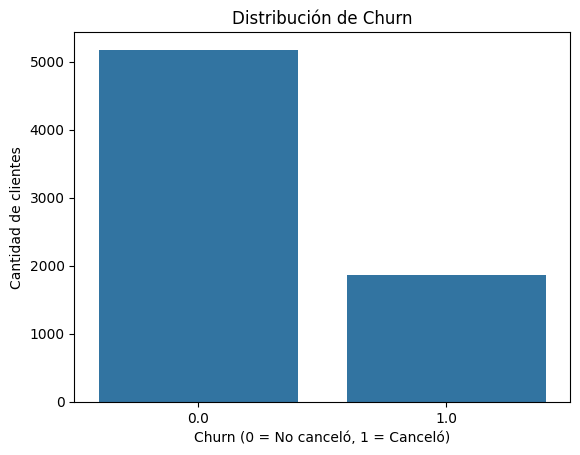

In [141]:
sns.countplot(x='Churn', data=df_final)

plt.title('Distribución de Churn')
plt.xlabel('Churn (0 = No canceló, 1 = Canceló)')
plt.ylabel('Cantidad de clientes')

plt.show()

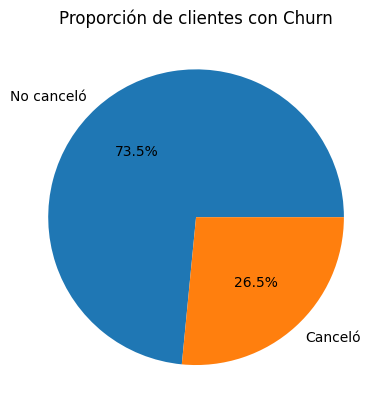

In [142]:
churn_counts = df_final['Churn'].value_counts()

plt.pie(churn_counts,
        labels=['No canceló','Canceló'],
        autopct='%1.1f%%')

plt.title('Proporción de clientes con Churn')

plt.show()

## Distribución de la variable Churn

Se realizaron visualizaciones para analizar la distribución de la variable Churn en el dataset.

Los gráficos muestran la cantidad y proporción de clientes que permanecieron en la empresa y aquellos que cancelaron el servicio. Este análisis permite comprender el nivel de evasión de clientes y sirve como punto de partida para identificar los factores que influyen en la cancelación del servicio.

#📄Informe final